In [1]:
import pandas as pd
import numpy as np

In [2]:
health_df = pd.read_csv('indexes_only.csv')

health_df.head()

,Unnamed: 0,no_show,E_HU,M_HU,E_HH,M_HH,E_POV150,M_POV150,E_UNEMP,M_UNEMP,...,r_SE_stt,r_COI_stt,c5_ED_met,c5_HE_met,c5_SE_met,c5_COI_met,r_ED_met,r_HE_met,r_SE_met,r_COI_met
0,0,Yes,1446.0,129.0,1399.0,136.0,1175.0,323.0,57.0,48.0,...,44.0,46.0,Moderate,Moderate,Moderate,Moderate,50.0,53.0,46.0,47.0
1,1,No,776.0,70.0,755.0,65.0,396.0,219.0,197.0,92.0,...,54.0,43.0,Low,Moderate,High,High,38.0,42.0,75.0,62.0
2,2,No,1284.0,86.0,1268.0,85.0,405.0,165.0,66.0,44.0,...,94.0,84.0,High,High,Very High,Very High,70.0,65.0,95.0,85.0
3,3,No,2429.0,182.0,2222.0,176.0,4217.0,1053.0,270.0,114.0,...,26.0,25.0,Low,Low,Low,Low,22.0,29.0,28.0,26.0
4,4,No,3171.0,460.0,3034.0,444.0,1176.0,687.0,160.0,111.0,...,78.0,86.0,Very High,Very High,High,Very High,94.0,91.0,80.0,88.0


In [3]:
label_map = {"Yes": 1, "No": 0}

y = health_df['no_show'].map(label_map)

X_raw = health_df.drop(columns=['no_show']).copy()

# Map ordered categorical levels to ordinal numbers when present
ordinal_map = {
    "very low": 0,
    "low": 1,
    "moderate": 2,
    "high": 3,
    "very high": 4,
}
ordered_cols = []

for col in X_raw.select_dtypes(include=["object", "category", "string"]).columns:
    cleaned = X_raw[col].astype(str).str.strip().str.lower().str.replace(r"[_-]", " ", regex=True)
    values = set(cleaned[X_raw[col].notna()].unique())

    if values and values.issubset(set(ordinal_map.keys())):
        X_raw[col] = cleaned.map(ordinal_map)
        ordered_cols.append(col)

# One-hot encode only the remaining non-ordered categorical columns
cat_cols = X_raw.select_dtypes(include=["object", "category", "string"]).columns.tolist()
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=False)

print("Ordered columns mapped:", ordered_cols)
print(X.head())

Ordered columns mapped: ['c5_ED_nat', 'c5_HE_nat', 'c5_SE_nat', 'c5_COI_nat', 'c5_ED_stt', 'c5_HE_stt', 'c5_SE_stt', 'c5_COI_stt', 'c5_ED_met', 'c5_HE_met', 'c5_SE_met', 'c5_COI_met']
   Unnamed: 0    E_HU   M_HU    E_HH   M_HH  E_POV150  M_POV150  E_UNEMP  \
0           0  1446.0  129.0  1399.0  136.0    1175.0     323.0     57.0   
1           1   776.0   70.0   755.0   65.0     396.0     219.0    197.0   
2           2  1284.0   86.0  1268.0   85.0     405.0     165.0     66.0   
3           3  2429.0  182.0  2222.0  176.0    4217.0    1053.0    270.0   
4           4  3171.0  460.0  3034.0  444.0    1176.0     687.0    160.0   

   M_UNEMP  E_HBURD  ...  r_SE_stt  r_COI_stt  c5_ED_met  c5_HE_met  \
0     48.0    484.0  ...      44.0       46.0        2.0        2.0   
1     92.0    223.0  ...      54.0       43.0        1.0        2.0   
2     44.0    296.0  ...      94.0       84.0        3.0        3.0   
3    114.0   1125.0  ...      26.0       25.0        1.0        1.0   
4   

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score
from xgboost import XGBClassifier

# Split into train/validation/test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

baseline_show_acc = (y_test == 0).mean()

precision_floor = 0.80
thresholds = np.arange(0.50, 0.991, 0.01)

model = XGBClassifier(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

val_probs = model.predict_proba(X_val)[:, 1]


test_probs = model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, test_probs >= 0.5)
test_precision = precision_score(y_test, test_probs >= 0.5)
test_recall = recall_score(y_test, test_probs >= 0.5)


print("Test accuracy:", round(float(test_acc), 4))
print("Test precision:", round(float(test_precision), 4))
print("Test recall:", round(float(test_recall), 4))

Test accuracy: 0.8765
Test precision: 0.6667
Test recall: 0.0003


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split


X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train_rf, y_train_rf)
rf_preds = rf_model.predict(X_test_rf)

rf_acc = accuracy_score(y_test_rf, rf_preds)
rf_precision = precision_score(y_test_rf, rf_preds, zero_division=0)
rf_recall = recall_score(y_test_rf, rf_preds, zero_division=0)

print("Random Forest accuracy:", round(float(rf_acc), 4))
print("Random Forest precision:", round(float(rf_precision), 4))
print("Random Forest recall:", round(float(rf_recall), 4))
print("\nClassification report:\n", classification_report(y_test_rf, rf_preds, zero_division=0))

Random Forest accuracy: 0.7683
Random Forest precision: 0.1739
Random Forest recall: 0.2335

Classification report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.86     92482
           1       0.17      0.23      0.20     13034

    accuracy                           0.77    105516
   macro avg       0.53      0.54      0.53    105516
weighted avg       0.80      0.77      0.78    105516



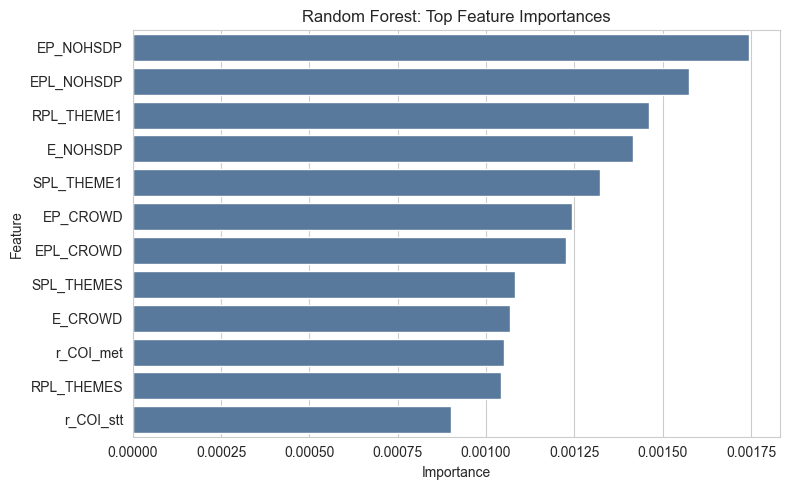

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# top feature importances from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Remove index-like columns
clean_importances = importances[~importances.index.str.contains(r"^Unnamed", case=False, regex=True)]

clean_importances = clean_importances.sort_values(ascending=False)
top_n = min(12, len(clean_importances))

plt.figure(figsize=(8, 5))
sns.barplot(
    x=clean_importances.head(top_n).values,
    y=clean_importances.head(top_n).index,
    color="#4E79A7",
)
plt.title("Random Forest: Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

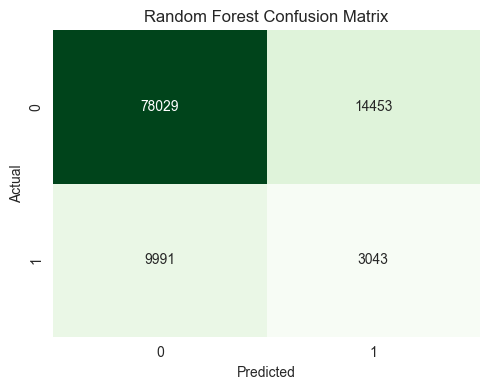

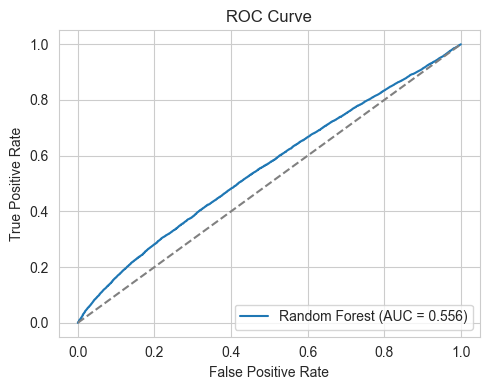

Classification Report (Random Forest)


,precision,recall,f1-score,support
0,0.886,0.844,0.865,92482.000
1,0.174,0.233,0.199,13034.000
accuracy,0.768,0.768,0.768,0.768
macro avg,0.530,0.539,0.532,105516.000
weighted avg,0.798,0.768,0.782,105516.000


In [7]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# confusion matrix
cm = confusion_matrix(y_test_rf, rf_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC curve
rf_probs = rf_model.predict_proba(X_test_rf)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rf, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Classification report
report_dict = classification_report(y_test_rf, rf_preds, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose().round(3)
print("Classification Report (Random Forest)")
display(report_df)